In [6]:
using Pkg
Pkg.activate(".")
Pkg.status()
using Revise, DifferentialEquations, ModelingToolkit, Catalyst, Plots, Latexify 

  Activating project at `c:\Users\Marcu\OneDrive - Danmarks Tekniske Universitet\Skrivebord\discovering_hidden_physics\notebooks`


Status `C:\Users\Marcu\OneDrive - Danmarks Tekniske Universitet\Skrivebord\discovering_hidden_physics\notebooks\Project.toml`
  [479239e8] Catalyst v16.2.0
  [0c46a032] DifferentialEquations v8.0.0
  [23fbe1c1] Latexify v0.16.10
  [961ee093] ModelingToolkit v11.28.2
  [91a5bcdd] Plots v1.41.6
  [295af30f] Revise v3.15.1


# Fermentation model
Model is adapted from the paper ["Dynamic Optimisation and Visualisation of Industrial Beer Fermentation with Explicit Heat Transfer Dynamics"](https://www.sciencedirect.com/science/chapter/bookseries/abs/pii/B9780128186343502447) Rodman et al. (2021). The model is a system of ODEs describing the dynamics of biomass, substrate, products, temperature, and feeding in a fermentation process. The code includes the definition of the model, simulation of the system, and plotting of the results.    

In [29]:
fermentation_model = @reaction_network begin
    @parameters begin
        #Initial conditions
        glucose_0 = 130.0   #g/L

        #Growth parameters (assumed time unit: hours, concentrations: g/L)
        μ_DT = 0.1            # 1/h  - death rate of active biomass
        μ_L = 0.005            # 1/h  - activation rate (latent -> active)
        μ_x0 = 1.0            # 1/h  - basal growth rate
        k_x = 5.0              # g/L  - half-saturation constant (for μ_x denominator)
        μ_SD0 = 0.25           # 1/h  - sloughing/death baseline rate
        μ_glucose_max = 1.2  # 1/h  - max glucose consumption rate
        k_glucose = 12.0       # g/L  - Monod constant for glucose
        μ_metabolite_max = 0.8  # 1/h  - max metabolite effect rate
        k_metabolite = 10.0       # g/L  - Monod constant for metabolite effect
        μ_DY = 0.05            #  empirical coeff for diacetyl formation (per g·L⁻¹·h)
        μ_AB = 0.01            #  empirical coeff for diacetyl removal (per g·L⁻¹·h)
        Y_EA = 0.5            # g ethyl_acetate / g biomass - yield (dimensionless)
        
        # #Temperature parameters 
        ΔH_total = .5       # J/g - total heat generated per g of glucose consumed (exothermic)
        T_C0 = 4.0             # °C - coolant temperature
        heat_transfer = 0.5    # 1/h - heat transfer coefficient between fermentor and jacket
        optimal_temperature = 25.0 # °C - optimal temperature for growth 
        sd_temp = 30.0          # °C - standard deviation for temperature effect (for Gaussian curve)
        
        #Oxygen parameters
        O_solubility = 2.0 # g/L - maximum dissolved oxygen concentration at given conditions 
        kla = 0.1            # 1/h - volumetric mass transfer coefficient for oxygen 
    end
    @species begin
        #Biomass species
        X_latent(t) = 3.0   # g/L - latent biomass concentration
        X_active(t) = 0.0   # g/L - active biomass concentration
        X_dead(t) = 1.0     # g/L - dead biomass concentration
    end

    @variables begin
        #Substrate and product concentrations
        glucose(t) = 130        # g/L
        metabolite(t) = 0.0        # g/L
        ethyl_acetate(t) = 0.0  # g/L
        diacetyl(t) = 0.0      # g/L

        #Temperature variables
        jacket_temperature(t) = 4.0       # °C
        fermentor_temperature(t) = 10.0   # °C
        coolant_rate(t) = 0.0                # L/min

        #Oxygen concentration 
        DO(t) = 10.0                     # g/L - dissolved oxygen concentration 
        OUR(t) = 0.0                    # g/L/h - oxygen uptake rate

        #Fed batch feed rate (time-varying input)
        F_feed(t) = 0.0                     # g/L/h - feed rate of glucose (can be time-varying)
        feed_on(t) = 0.0                    # unitless - feed control signal (0 or 1)

        μ_x(t)         # 1/h - instantaneous growth rate
        μ_SD(t)        # 1/h - sloughing/death rate
        μ_glucose(t)   # 1/h - glucose-driven growth contribution
        μ_metabolite(t)   # 1/h - metabolite-driven rate
        X_total(t)       # g/L - total biomass concentration (latent + active + dead)
    end

    @equations begin
        X_total ~ X_latent + X_active + X_dead

        #Growth rates
        μ_x ~ μ_x0 * (glucose / (k_x + glucose))*exp(-(fermentor_temperature - optimal_temperature)^2/(2*sd_temp^2)) # Temperature effect on growth (Gaussian centered at optimal temperature)
        μ_SD ~ μ_SD0 * (0.5*glucose_0/(0.5*glucose_0 + metabolite))
        μ_glucose ~ μ_glucose_max * (glucose / (k_glucose + glucose))
        μ_metabolite ~ μ_metabolite_max * (glucose / (k_metabolite + glucose))
 
        #Feed control logic (simple on/off based on glucose concentration) 
        F_feed ~ feed_on * μ_glucose * X_active
        D(feed_on) ~ 0.0

        #Dynamics of products and by-products
        D(glucose) ~ -μ_glucose * X_active + F_feed
        D(metabolite) ~ μ_metabolite * X_active * (1 - metabolite / (0.5 * glucose_0))
        D(ethyl_acetate) ~ Y_EA * μ_x * X_active
        D(diacetyl) ~ μ_DY * X_active * glucose - μ_AB * diacetyl * metabolite
 
        #Temperature dynamics
        D(coolant_rate) ~ 0.0           # Treat coolant_rate as a control input (constant or time-varying)
        D(fermentor_temperature) ~  μ_glucose * X_active * ΔH_total - heat_transfer * (fermentor_temperature - jacket_temperature)
        D(jacket_temperature) ~ coolant_rate * (T_C0 - jacket_temperature) + heat_transfer * (fermentor_temperature - jacket_temperature )

        #Oxygen dynamics 
        D(DO) ~ -OUR + kla * (O_solubility - DO) # Simple oxygen dynamics with uptake and re-aeration
        OUR ~ 0.1 * μ_x * X_active # Oxygen uptake rate proportional to growth rate and active biomass
    end

    #Cell growth and death       
    μ_L,    X_latent --> X_active
    μ_x,    X_active --> 2X_active 
    μ_DT,   X_active --> X_dead 
    μ_SD,   X_dead --> ∅
end 

Model ##ReactionSystem#403:
Unknowns (19): see unknowns(##ReactionSystem#403)
  X_latent(t)
  X_active(t)
  X_dead(t)
  glucose(t)
  ⋮
Parameters (20): see parameters(##ReactionSystem#403)
  glucose_0
  μ_DT
  μ_L
  μ_x0
  ⋮

# Simulation and Feeding / Temperature Control
The code shows how to use callbacks in the `DifferentialEquations.jl` framework to implement feeding and temperature control strategies. The callbacks are defined to trigger at specific conditions, such as when the substrate concentration falls below a certain threshold or when the fermentor temperature exceeds a set point. The simulation is then run with these callbacks to observe the system's response to the control actions.  

In [30]:
@unpack X_active, X_latent, X_dead, X_total, μ_x, μ_SD, μ_glucose, μ_metabolite = fermentation_model



@named odesys = Catalyst.ode_model(fermentation_model)#convert(ODESystem, fermentation_model)
odesys = structural_simplify(odesys) 

idx_dict = Dict(zip(string.(unknowns(odesys)), 1:length(unknowns(fermentation_model))))
    



#events
#Temperature control parameters
condition(u, t, integrator) = u[idx_dict["fermentor_temperature(t)"]] > 35.0 # Trigger when fermentor temperature exceeds 30°C
affect!(integrator) = (integrator.u[idx_dict["coolant_rate(t)"]] = 0.5) # Set coolant_rate to 0.5 L/min when triggered
cb = DiscreteCallback(condition, affect!) 
condition_stop(u, t, integrator) = u[idx_dict["fermentor_temperature(t)"]] < 10.0 # Stop when fermentor temperature drops below 10°C
affect_stop!(integrator) = (integrator.u[idx_dict["coolant_rate(t)"]] = 0.) # Set coolant_rate back to 0 when stopped
cb_stop = DiscreteCallback(condition_stop, affect_stop!)
#Feed control parameters
condition_feed(u, t, integrator) = u[idx_dict["glucose(t)"]] < 100.0 # Trigger when glucose concentration exceeds 0.5 g/L
affect_feed!(integrator) = (integrator.u[idx_dict["feed_on(t)"]] = 1.0) # Set feed_on to 1.0 when triggered
cb_feed = DiscreteCallback(condition_feed, affect_feed!)
condition_feed_stop(u, t, integrator) = t >= 100.0 # Stop feed after 50 hours
affect_feed_stop!(integrator) = (integrator.u[idx_dict["feed_on(t)"]] = 0.0) # Set feed_on back to 0 when stopped
cb_feed_stop = DiscreteCallback(condition_feed_stop, affect_feed_stop!)

cb_combined = CallbackSet(cb, cb_stop, cb_feed, cb_feed_stop)   

prob = ODEProblem(odesys, [], (0.0, 150.0), callback=cb_combined, warn_initialize_determined = false)
prob = remake(prob, p = pdict)

sol = solve(prob, Tsit5(), saveat=0.1)      

┌ Warning: Initialization system is overdetermined. 5 equations for 3 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here.
│ 
│ 
│ To suppress this warning, pass `warn_initialize_determined = false`. To turn this warning into an error, pass `fully_determined = true`.
└ @ ModelingToolkit C:\Users\Marcu\.julia\packages\ModelingToolkit\bRzOa\src\initialization.jl:22


retcode: Success
Interpolation: 1st order linear
t: 1708-element Vector{Float64}:
   0.0
   0.05123221321467449
   0.05123221321467449
   0.1
   0.2
   0.29283019322933296
   0.29283019322933296
   0.3
   0.4
   0.5
   ⋮
 149.7
 149.8
 149.9
 150.0
 150.0
 150.0
 150.0
 150.0
 150.0
u: 1708-element Vector{Vector{Float64}}:
 [10.0, 4.0, 10.0, 0.0, 0.0, 0.0, 0.0, 130.0, 0.0, 1.0, 0.0, 3.0]
 [9.959118706417314, 4.149826004515095, 9.850184811396952, 0.0, 0.00012798828260480365, 1.6705112859579465e-6, 1.4627231803847065e-5, 129.9999783681759, 0.0, 0.9872765626996762, 0.0007687722254557082, 2.9992316152211136]
 [9.959118706417314, 4.149826004515095, 9.850184811396952, 0.0, 0.00012798828260480365, 1.6705112859579465e-6, 1.4627231803847065e-5, 129.9999783681759, 0.0, 0.9872765626996762, 0.0007687722254557082, 2.9992316152211136]
 [9.920397402997938, 4.285488730481788, 9.714552486689364, 0.0, 0.0004877363743475805, 6.356092222504897e-6, 5.574129349368709e-5, 129.99991756565768, 0.0, 0.975321081

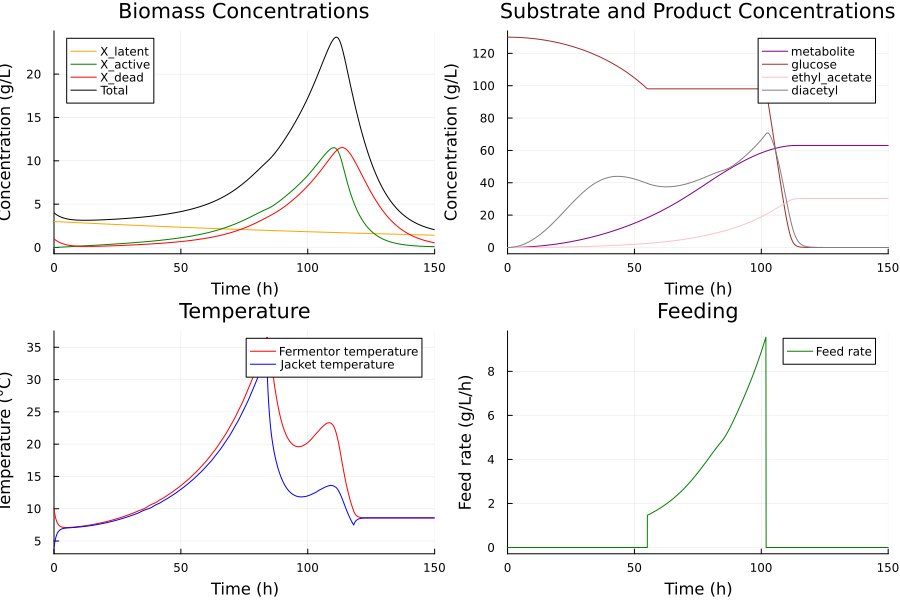

In [31]:
#plot tempereature dynamics
p_temperature = plot(sol, idxs = [:fermentor_temperature, :jacket_temperature], labels=hcat(["Fermentor temperature", "Jacket temperature"]...), title = "Temperature", 
    xlabel = "Time (h)", ylabel = "Temperature (°C)", color = [:red :blue])
#plot feeding dynamics
p_feeding = plot(sol, idxs = :F_feed, labels="Feed rate", title = "Feeding", xlabel = "Time (h)", ylabel = "Feed rate (g/L/h)", color=:green)

# p_growth_death = plot(sol, idxs = [μ_x, μ_SD], labels=hcat(["μ_x", "μ_SD"]...), title = "Growth and Death Rates", xlabel = "Time (h)", ylabel = "Rate (1/h)")

p_biomass = plot(sol, idxs = [:X_latent, :X_active, :X_dead, X_latent + X_active + X_dead], labels=hcat(["X_latent", "X_active", "X_dead", "Total"]...), title = "Biomass Concentrations", xlabel = "Time (h)", ylabel = "Concentration (g/L)", color=[:orange :green :red :black])
#plot the substrate and products
p_substrate_products = plot(sol, idxs = [:metabolite, :glucose, :ethyl_acetate, :diacetyl], labels=hcat(["metabolite", "glucose", "ethyl_acetate", "diacetyl"]...), title = "Substrate and Product Concentrations", xlabel = "Time (h)", ylabel = "Concentration (g/L)", color=[:purple :brown :pink :gray])

#combine the plots
final_plot = plot(p_biomass, p_substrate_products, p_temperature, p_feeding, layout=(2,2), size=(900,600))



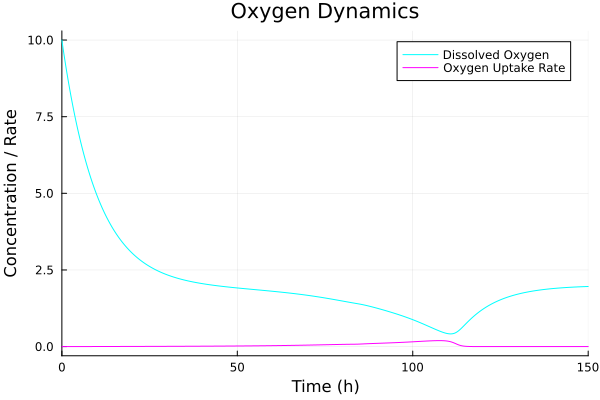

In [32]:
#plot dissolved oxygen and OUR
p_oxygen = plot(sol, idxs = [:DO, :OUR], labels=hcat(["Dissolved Oxygen", "Oxygen Uptake Rate"]...), title = "Oxygen Dynamics", xlabel = "Time (h)", ylabel = "Concentration / Rate", color=[:cyan :magenta])   